In [ ]:
!pip install -q mediapipe opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 10.4 MB/s eta 0:00:00


In [ ]:
import mediapipe as mp

print(mp.__version__)
print(dir(mp))

0.10.35
['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']


In [ ]:
!pip install -q kaggle

In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_dd900fec06fe1e63c14ed6cfa2ef8776"

In [ ]:
!kaggle datasets download -d shyambhu/hands-and-palm-images-dataset

Dataset URL: https://www.kaggle.com/datasets/shyambhu/hands-and-palm-images-dataset
License(s): DbCL-1.0
100% 634M/634M [00:30<00:00, 22.0MB/s]



In [ ]:
!unzip -q /content/hands-and-palm-images-dataset.zip -d /content/palm_dataset

In [ ]:
folder = "/content/palm_dataset/Hands/Hands"

files = os.listdir(folder)

print("Total Images:", len(files))

Total Images: 11076


In [ ]:
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [ ]:
# Create Hand Landmarker

BaseOptions = mp.tasks.BaseOptions
HandLandmarker = vision.HandLandmarker
HandLandmarkerOptions = vision.HandLandmarkerOptions
VisionRunningMode = vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="hand_landmarker.task"),
    num_hands=1,
    running_mode=VisionRunningMode.IMAGE
)

detector = HandLandmarker.create_from_options(options)

print("Hand Landmarker Loaded Successfully!")

Hand Landmarker Loaded Successfully!


In [ ]:
image_folder = "/content/palm_dataset/Hands/Hands"

image_list = sorted(os.listdir(image_folder))

print("Total Images:", len(image_list))

sample_image = os.path.join(image_folder, image_list[0])

print(sample_image)

Total Images: 11076
/content/palm_dataset/Hands/Hands/Hand_0000002.jpg


In [ ]:
image = mp.Image.create_from_file(sample_image)

print(image)

In [ ]:
detection_result = detector.detect(image)

print(detection_result)

HandLandmarkerResult(handedness=[[Category(index=0, score=0.9370512962341309, display_name='Right', category_name='Right')]], hand_landmarks=[[NormalizedLandmark(x=0.4516398310661316, y=-0.125843346118927, z=4.011946259652177e-07, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.5773233771324158, y=-0.03422477841377258, z=-0.03625696897506714, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.6506959199905396, y=0.11081816256046295, z=-0.0716819316148758, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7043852806091309, y=0.2548108994960785, z=-0.10326339304447174, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7784839272499084, y=0.33818742632865906, z=-0.13902190327644348, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.581730306148529, y=0.29229065775871277, z=-0.093612439930439, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.5945825576782227, y=0.5204761028289795, z=-0.1

In [ ]:
print("Hands Detected:", len(detection_result.hand_landmarks))

if len(detection_result.hand_landmarks) > 0:
    print("Palm Detected Successfully!")
else:
    print("No Palm Found")

Hands Detected: 1
Palm Detected Successfully!


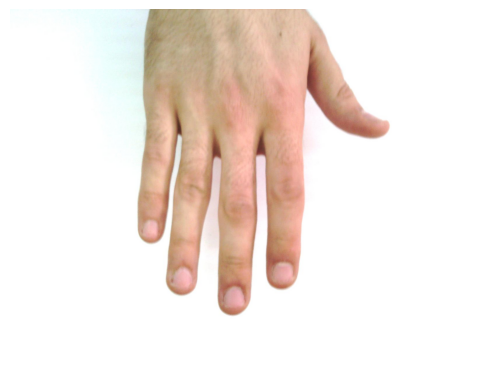

In [ ]:
img = cv2.imread(sample_image)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
landmarks = detection_result.hand_landmarks[0]

for i, landmark in enumerate(landmarks):
    print(
        f"Landmark {i}: "
        f"x={landmark.x:.4f}, "
        f"y={landmark.y:.4f}, "
        f"z={landmark.z:.4f}"
    )

Landmark 0: x=0.4516, y=-0.1258, z=0.0000
Landmark 1: x=0.5773, y=-0.0342, z=-0.0363
Landmark 2: x=0.6507, y=0.1108, z=-0.0717
Landmark 3: x=0.7044, y=0.2548, z=-0.1033
Landmark 4: x=0.7785, y=0.3382, z=-0.1390
Landmark 5: x=0.5817, y=0.2923, z=-0.0936
Landmark 6: x=0.5946, y=0.5205, z=-0.1402
Landmark 7: x=0.5953, y=0.6614, z=-0.1672
Landmark 8: x=0.5921, y=0.7738, z=-0.1852
Landmark 9: x=0.4874, y=0.2991, z=-0.1023
Landmark 10: x=0.4883, y=0.5496, z=-0.1480
Landmark 11: x=0.4840, y=0.7088, z=-0.1756
Landmark 12: x=0.4786, y=0.8372, z=-0.1943
Landmark 13: x=0.4025, y=0.2747, z=-0.1110
Landmark 14: x=0.3877, y=0.5094, z=-0.1531
Landmark 15: x=0.3740, y=0.6610, z=-0.1821
Landmark 16: x=0.3675, y=0.7811, z=-0.1996
Landmark 17: x=0.3298, y=0.2324, z=-0.1201
Landmark 18: x=0.3122, y=0.4168, z=-0.1538
Landmark 19: x=0.3030, y=0.5318, z=-0.1693
Landmark 20: x=0.2993, y=0.6306, z=-0.1776


In [ ]:
import pandas as pd

rows = []

for i, lm in enumerate(landmarks):
    rows.append([i, lm.x, lm.y, lm.z])

df = pd.DataFrame(rows, columns=["Landmark", "X", "Y", "Z"])

df.head()

,Landmark,X,Y,Z
0,0,0.451640,-0.125843,4.011946e-07
1,1,0.577323,-0.034225,-3.625697e-02
2,2,0.650696,0.110818,-7.168193e-02
3,3,0.704385,0.254811,-1.032634e-01
4,4,0.778484,0.338187,-1.390219e-01


In [ ]:
df.to_csv("sample_landmarks.csv", index=False)

print("Saved Successfully!")

Saved Successfully!


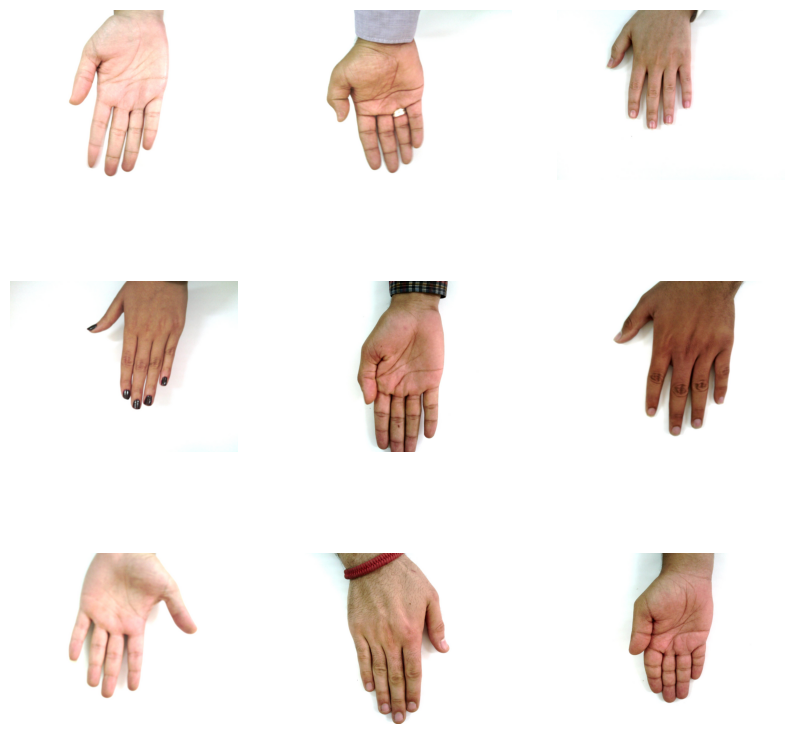

In [ ]:
import random

image_folder = "/content/palm_dataset/Hands/Hands"

random_images = random.sample(os.listdir(image_folder), 9)

plt.figure(figsize=(10,10))

for i, img_name in enumerate(random_images):
    img = cv2.imread(os.path.join(image_folder, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [ ]:
import pandas as pd

csv_path = "/content/palm_dataset/HandInfo.csv"

df = pd.read_csv(csv_path)

print(df.columns)
print(df["aspectOfHand"].value_counts())

Index(['id', 'age', 'gender', 'skinColor', 'accessories', 'nailPolish',
       'aspectOfHand', 'imageName', 'irregularities'],
      dtype='object')
aspectOfHand
dorsal right    2892
palmar right    2813
dorsal left     2788
palmar left     2583
Name: count, dtype: int64


In [ ]:
df["aspectOfHand"].value_counts()

,count
aspectOfHand,
dorsal right,2892
palmar right,2813
dorsal left,2788
palmar left,2583


In [ ]:
import pandas as pd
import os

csv_path = "/content/palm_dataset/HandInfo.csv"

df = pd.read_csv(csv_path)

# Keep only palm images
palm_df = df[df["aspectOfHand"].str.contains("palmar")].copy()

print("Total Palm Images:", len(palm_df))

palm_df.head()

Total Palm Images: 5396


,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
30,0,27,male,fair,1,0,palmar left,Hand_0000038.jpg,0
31,0,27,male,fair,1,0,palmar left,Hand_0000039.jpg,0
32,0,27,male,fair,1,0,palmar left,Hand_0000040.jpg,0
33,0,27,male,fair,1,0,palmar left,Hand_0000041.jpg,0
34,0,27,male,fair,1,0,palmar left,Hand_0000042.jpg,0


In [ ]:
image_folder = "/content/palm_dataset/Hands/Hands"

palm_df["image_path"] = palm_df["imageName"].apply(
    lambda x: os.path.join(image_folder, x)
)

palm_df.head()

,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities,image_path
30,0,27,male,fair,1,0,palmar left,Hand_0000038.jpg,0,/content/palm_dataset/Hands/Hands/Hand_0000038...
31,0,27,male,fair,1,0,palmar left,Hand_0000039.jpg,0,/content/palm_dataset/Hands/Hands/Hand_0000039...
32,0,27,male,fair,1,0,palmar left,Hand_0000040.jpg,0,/content/palm_dataset/Hands/Hands/Hand_0000040...
33,0,27,male,fair,1,0,palmar left,Hand_0000041.jpg,0,/content/palm_dataset/Hands/Hands/Hand_0000041...
34,0,27,male,fair,1,0,palmar left,Hand_0000042.jpg,0,/content/palm_dataset/Hands/Hands/Hand_0000042...


/content/palm_dataset/Hands/Hands/Hand_0000256.jpg


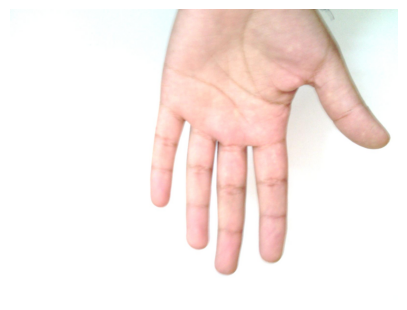

In [ ]:
sample_path = palm_df.iloc[100]["image_path"]

print(sample_path)

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
image = mp.Image.create_from_file(sample_path)

result = detector.detect(image)

print("Hands Detected:", len(result.hand_landmarks))

Hands Detected: 1


In [ ]:
landmarks = result.hand_landmarks[0]

for i, lm in enumerate(landmarks):
    print(
        f"{i}: "
        f"x={lm.x:.4f}, "
        f"y={lm.y:.4f}, "
        f"z={lm.z:.4f}"
    )

0: x=0.6081, y=-0.0800, z=0.0000
1: x=0.7285, y=0.0243, z=-0.0668
2: x=0.8098, y=0.1844, z=-0.1045
3: x=0.8652, y=0.3336, z=-0.1385
4: x=0.9281, y=0.4334, z=-0.1728
5: x=0.6624, y=0.3968, z=-0.0527
6: x=0.6738, y=0.5984, z=-0.0955
7: x=0.6762, y=0.7236, z=-0.1351
8: x=0.6753, y=0.8320, z=-0.1651
9: x=0.5793, y=0.4009, z=-0.0516
10: x=0.5675, y=0.6174, z=-0.0883
11: x=0.5602, y=0.7570, z=-0.1247
12: x=0.5519, y=0.8730, z=-0.1528
13: x=0.5067, y=0.3612, z=-0.0596
14: x=0.4843, y=0.5568, z=-0.0933
15: x=0.4793, y=0.6779, z=-0.1264
16: x=0.4786, y=0.7827, z=-0.1500
17: x=0.4389, y=0.2926, z=-0.0747
18: x=0.4016, y=0.4448, z=-0.1029
19: x=0.3904, y=0.5484, z=-0.1227
20: x=0.3839, y=0.6448, z=-0.1373


In [ ]:
import pandas as pd
import os

all_landmarks = []

total = len(palm_df)

for index, row in palm_df.iterrows():

    image_path = row["image_path"]

    try:
        image = mp.Image.create_from_file(image_path)

        result = detector.detect(image)

        if len(result.hand_landmarks) == 0:
            continue

        landmarks = result.hand_landmarks[0]

        feature_row = {
            "imageName": row["imageName"],
            "aspectOfHand": row["aspectOfHand"]
        }

        for i, lm in enumerate(landmarks):
            feature_row[f"x{i}"] = lm.x
            feature_row[f"y{i}"] = lm.y
            feature_row[f"z{i}"] = lm.z

        all_landmarks.append(feature_row)

    except Exception:
        continue

    if len(all_landmarks) % 500 == 0:
        print(f"Processed {len(all_landmarks)} images")

print("Finished!")

Processed 500 images
Processed 1000 images
Processed 1500 images
Processed 2000 images
Processed 2500 images
Processed 3000 images
Processed 3500 images
Processed 4000 images
Processed 4500 images
Processed 5000 images
Finished!


In [ ]:
landmark_df = pd.DataFrame(all_landmarks)

print(landmark_df.shape)

landmark_df.head()

(5380, 65)


,imageName,aspectOfHand,x0,y0,z0,x1,y1,z1,x2,y2,...,z17,x18,y18,z18,x19,y19,z19,x20,y20,z20
0,Hand_0000038.jpg,palmar left,0.689648,-0.112166,5.700653e-07,0.778413,-0.056408,-0.075073,0.843150,0.030598,...,-0.100837,0.531347,0.363433,-0.138638,0.508779,0.461021,-0.158637,0.493003,0.549509,-0.170967
1,Hand_0000039.jpg,palmar left,0.562883,-0.106192,7.584205e-07,0.673490,-0.061281,-0.081761,0.767951,0.017259,...,-0.107748,0.407883,0.376951,-0.144655,0.382444,0.468299,-0.166967,0.360762,0.553821,-0.181654
2,Hand_0000040.jpg,palmar left,0.525117,-0.112016,7.360968e-07,0.628401,-0.065439,-0.088009,0.720585,0.014696,...,-0.108027,0.368982,0.363798,-0.144217,0.343580,0.453193,-0.165765,0.322112,0.537508,-0.180143
3,Hand_0000041.jpg,palmar left,0.514513,-0.091481,8.521814e-07,0.627270,-0.051181,-0.097795,0.726459,0.022672,...,-0.111220,0.370047,0.390945,-0.151134,0.346630,0.481928,-0.176910,0.327445,0.567986,-0.195057
4,Hand_0000042.jpg,palmar left,0.526333,-0.078922,8.896413e-07,0.642185,-0.030952,-0.097638,0.738901,0.045883,...,-0.099267,0.375494,0.413256,-0.135712,0.352075,0.505117,-0.159493,0.331952,0.592429,-0.176405


In [ ]:
landmark_df.to_csv("/content/palm_features.csv", index=False)

print("CSV Saved Successfully!")

CSV Saved Successfully!


In [ ]:
landmark_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5380 entries, 0 to 5379
Data columns (total 65 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   imageName     5380 non-null   object 
 1   aspectOfHand  5380 non-null   object 
 2   x0            5380 non-null   float64
 3   y0            5380 non-null   float64
 4   z0            5380 non-null   float64
 5   x1            5380 non-null   float64
 6   y1            5380 non-null   float64
 7   z1            5380 non-null   float64
 8   x2            5380 non-null   float64
 9   y2            5380 non-null   float64
 10  z2            5380 non-null   float64
 11  x3            5380 non-null   float64
 12  y3            5380 non-null   float64
 13  z3            5380 non-null   float64
 14  x4            5380 non-null   float64
 15  y4            5380 non-null   float64
 16  z4            5380 non-null   float64
 17  x5            5380 non-null   float64
 18  y5            5380 non-null 

In [ ]:
landmark_df.isnull().sum()

,0
imageName,0
aspectOfHand,0
x0,0
y0,0
z0,0
...,...
y19,0
z19,0
x20,0
y20,0


In [ ]:
landmark_df.head()

,imageName,aspectOfHand,x0,y0,z0,x1,y1,z1,x2,y2,...,z17,x18,y18,z18,x19,y19,z19,x20,y20,z20
0,Hand_0000038.jpg,palmar left,0.689648,-0.112166,5.700653e-07,0.778413,-0.056408,-0.075073,0.843150,0.030598,...,-0.100837,0.531347,0.363433,-0.138638,0.508779,0.461021,-0.158637,0.493003,0.549509,-0.170967
1,Hand_0000039.jpg,palmar left,0.562883,-0.106192,7.584205e-07,0.673490,-0.061281,-0.081761,0.767951,0.017259,...,-0.107748,0.407883,0.376951,-0.144655,0.382444,0.468299,-0.166967,0.360762,0.553821,-0.181654
2,Hand_0000040.jpg,palmar left,0.525117,-0.112016,7.360968e-07,0.628401,-0.065439,-0.088009,0.720585,0.014696,...,-0.108027,0.368982,0.363798,-0.144217,0.343580,0.453193,-0.165765,0.322112,0.537508,-0.180143
3,Hand_0000041.jpg,palmar left,0.514513,-0.091481,8.521814e-07,0.627270,-0.051181,-0.097795,0.726459,0.022672,...,-0.111220,0.370047,0.390945,-0.151134,0.346630,0.481928,-0.176910,0.327445,0.567986,-0.195057
4,Hand_0000042.jpg,palmar left,0.526333,-0.078922,8.896413e-07,0.642185,-0.030952,-0.097638,0.738901,0.045883,...,-0.099267,0.375494,0.413256,-0.135712,0.352075,0.505117,-0.159493,0.331952,0.592429,-0.176405


In [ ]:
landmark_df["aspectOfHand"].value_counts()

,count
aspectOfHand,
palmar right,2797
palmar left,2583


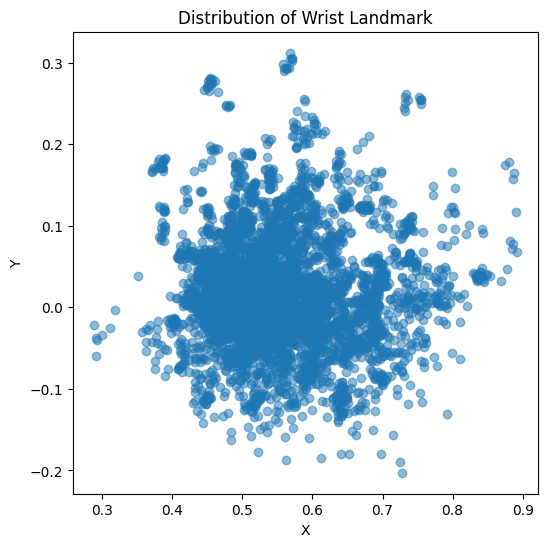

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(
    landmark_df["x0"],
    landmark_df["y0"],
    alpha=0.5
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Distribution of Wrist Landmark")

plt.show()

In [ ]:
landmark_df.to_csv("/content/palm_landmarks_dataset.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/palm_features.csv")

print(df.shape)
df.head()

(5380, 65)


,imageName,aspectOfHand,x0,y0,z0,x1,y1,z1,x2,y2,...,z17,x18,y18,z18,x19,y19,z19,x20,y20,z20
0,Hand_0000038.jpg,palmar left,0.689648,-0.112166,5.700653e-07,0.778413,-0.056408,-0.075073,0.843150,0.030598,...,-0.100837,0.531347,0.363433,-0.138638,0.508779,0.461021,-0.158637,0.493003,0.549509,-0.170967
1,Hand_0000039.jpg,palmar left,0.562883,-0.106192,7.584205e-07,0.673490,-0.061281,-0.081761,0.767951,0.017259,...,-0.107748,0.407883,0.376951,-0.144655,0.382444,0.468299,-0.166967,0.360762,0.553821,-0.181654
2,Hand_0000040.jpg,palmar left,0.525117,-0.112016,7.360968e-07,0.628401,-0.065439,-0.088009,0.720585,0.014696,...,-0.108027,0.368982,0.363798,-0.144217,0.343580,0.453193,-0.165765,0.322112,0.537508,-0.180143
3,Hand_0000041.jpg,palmar left,0.514513,-0.091481,8.521814e-07,0.627270,-0.051181,-0.097795,0.726459,0.022672,...,-0.111220,0.370047,0.390945,-0.151134,0.346630,0.481928,-0.176910,0.327445,0.567986,-0.195057
4,Hand_0000042.jpg,palmar left,0.526333,-0.078922,8.896413e-07,0.642185,-0.030952,-0.097638,0.738901,0.045883,...,-0.099267,0.375494,0.413256,-0.135712,0.352075,0.505117,-0.159493,0.331952,0.592429,-0.176405


In [ ]:
import numpy as np

df["palm_width"] = np.sqrt(
    (df["x5"] - df["x17"])**2 +
    (df["y5"] - df["y17"])**2
)

In [ ]:
df["palm_height"] = np.sqrt(
    (df["x0"] - df["x9"])**2 +
    (df["y0"] - df["y9"])**2
)

In [ ]:
df["thumb_length"] = np.sqrt(
    (df["x2"]-df["x4"])**2 +
    (df["y2"]-df["y4"])**2
)

In [ ]:
df["index_length"] = np.sqrt(
    (df["x5"]-df["x8"])**2 +
    (df["y5"]-df["y8"])**2
)

In [ ]:
df["middle_length"] = np.sqrt(
    (df["x9"]-df["x12"])**2 +
    (df["y9"]-df["y12"])**2
)

In [ ]:
df["ring_length"] = np.sqrt(
    (df["x13"]-df["x16"])**2 +
    (df["y13"]-df["y16"])**2
)

In [ ]:
df["little_length"] = np.sqrt(
    (df["x17"]-df["x20"])**2 +
    (df["y17"]-df["y20"])**2
)

In [ ]:
df["palm_ratio"] = df["palm_height"] / df["palm_width"]

In [ ]:
df.to_csv("/content/palm_engineered_features.csv", index=False)

print("Engineered features saved successfully.")

Engineered features saved successfully.


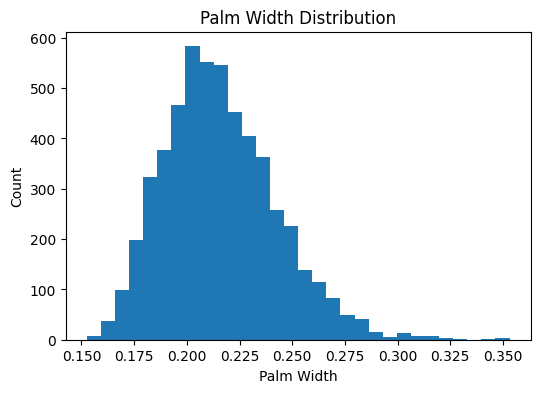

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["palm_width"], bins=30)
plt.title("Palm Width Distribution")
plt.xlabel("Palm Width")
plt.ylabel("Count")
plt.show()

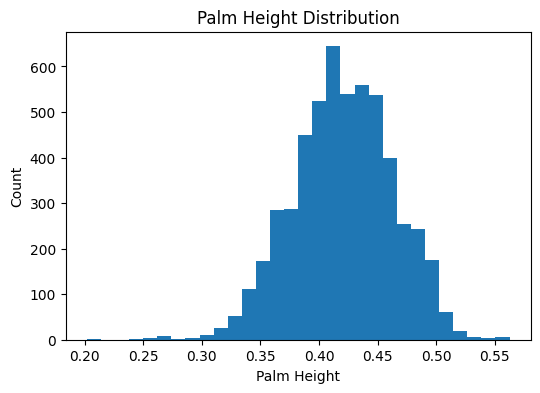

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["palm_height"], bins=30)
plt.title("Palm Height Distribution")
plt.xlabel("Palm Height")
plt.ylabel("Count")
plt.show()

In [ ]:
summary = df[[
    "palm_width",
    "palm_height",
    "thumb_length",
    "index_length",
    "middle_length",
    "ring_length",
    "little_length",
    "palm_ratio"
]].describe()

summary

,palm_width,palm_height,thumb_length,index_length,middle_length,ring_length,little_length,palm_ratio
count,5380.000000,5380.000000,5380.000000,5380.000000,5380.000000,5380.000000,5380.000000,5380.000000
mean,0.216021,0.420677,0.240516,0.354858,0.390093,0.360817,0.288504,1.960611
std,0.026794,0.042548,0.028609,0.040771,0.043693,0.041253,0.034952,0.182291
min,0.152519,0.201856,0.098943,0.264881,0.289326,0.266943,0.188585,0.909557
25%,0.196906,0.392745,0.221520,0.326008,0.358241,0.331514,0.264126,1.854419
50%,0.213150,0.420379,0.238751,0.347592,0.383916,0.355673,0.285812,1.968707
75%,0.232548,0.450231,0.258857,0.378850,0.414812,0.384178,0.308687,2.083710
max,0.353092,0.562516,0.368224,0.517666,0.572210,0.539778,0.418572,2.536204


In [ ]:
summary.to_csv("/content/palm_feature_summary.csv")

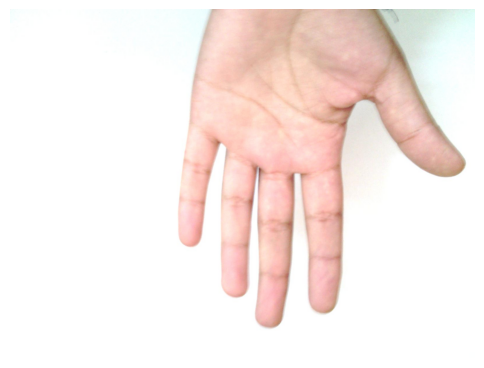

In [ ]:
sample_path = palm_df.iloc[100]["image_path"]

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

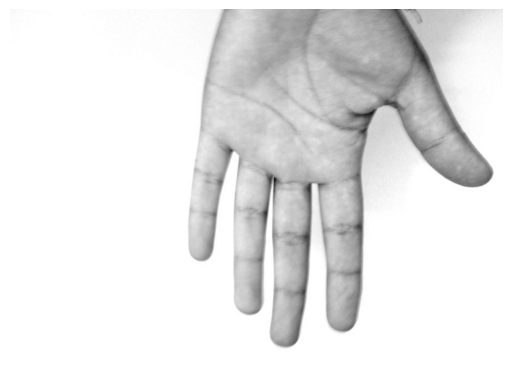

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

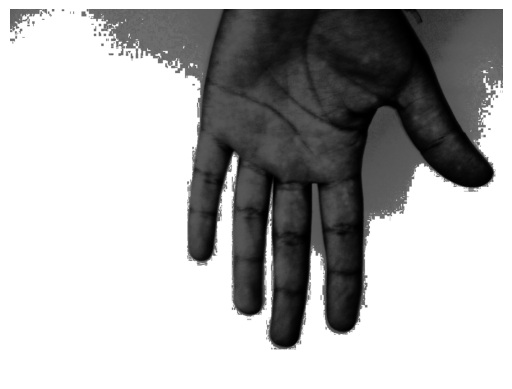

In [ ]:
gray = cv2.equalizeHist(gray)

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

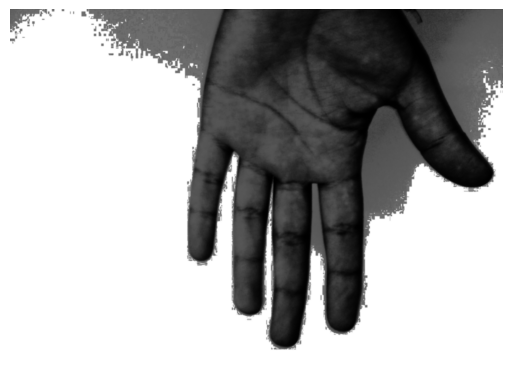

In [ ]:
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.imshow(blur, cmap="gray")
plt.axis("off")
plt.show()

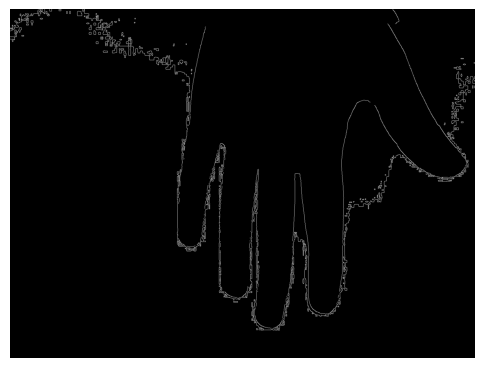

In [ ]:
edges = cv2.Canny(blur, 40, 120)

plt.figure(figsize=(6,6))
plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.show()

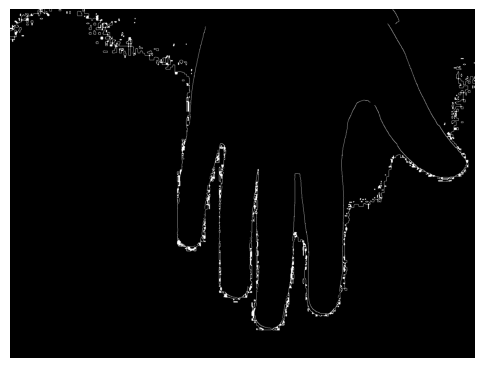

In [ ]:
kernel = np.ones((3,3), np.uint8)

lines = cv2.dilate(edges, kernel, iterations=1)
lines = cv2.erode(lines, kernel, iterations=1)

plt.figure(figsize=(6,6))
plt.imshow(lines, cmap="gray")
plt.axis("off")
plt.show()

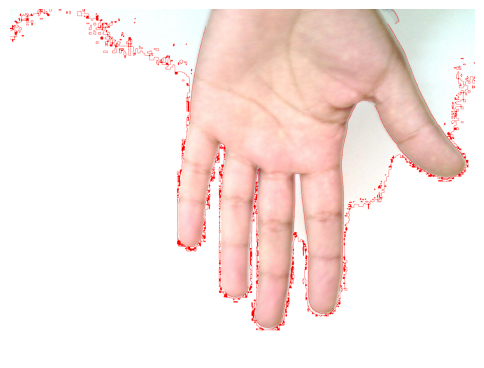

In [ ]:
overlay = img.copy()

overlay[lines > 0] = [255, 0, 0]

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.axis("off")
plt.show()

In [ ]:
def classify_palm(width, height):
    ratio = height / width

    if ratio > 1.3:
        return "Long Palm"
    elif ratio < 1.0:
        return "Square Palm"
    else:
        return "Rectangular Palm"

In [ ]:
df["palm_shape"] = df.apply(
    lambda row: classify_palm(
        row["palm_width"],
        row["palm_height"]
    ),
    axis=1
)

df["palm_shape"].value_counts()

,count
palm_shape,
Long Palm,5361
Rectangular Palm,18
Square Palm,1


In [ ]:
import pandas as pd

df = pd.read_csv("/content/palm_features.csv")

In [ ]:
import pandas as pd

df = pd.read_csv("/content/palm_engineered_features.csv")

df.head()

,imageName,aspectOfHand,x0,y0,z0,x1,y1,z1,x2,y2,...,y20,z20,palm_width,palm_height,thumb_length,index_length,middle_length,ring_length,little_length,palm_ratio
0,Hand_0000038.jpg,palmar left,0.689648,-0.112166,5.700653e-07,0.778413,-0.056408,-0.075073,0.843150,0.030598,...,0.549509,-0.170967,0.240354,0.411515,0.142926,0.385593,0.441284,0.415338,0.339090,1.712118
1,Hand_0000039.jpg,palmar left,0.562883,-0.106192,7.584205e-07,0.673490,-0.061281,-0.081761,0.767951,0.017259,...,0.553821,-0.181654,0.230373,0.417251,0.224987,0.390255,0.432836,0.402979,0.332628,1.811200
2,Hand_0000040.jpg,palmar left,0.525117,-0.112016,7.360968e-07,0.628401,-0.065439,-0.088009,0.720585,0.014696,...,0.537508,-0.180143,0.228016,0.418858,0.222953,0.385329,0.426618,0.398870,0.327895,1.836966
3,Hand_0000041.jpg,palmar left,0.514513,-0.091481,8.521814e-07,0.627270,-0.051181,-0.097795,0.726459,0.022672,...,0.567986,-0.195057,0.232702,0.417587,0.228271,0.395647,0.438817,0.406156,0.331233,1.794512
4,Hand_0000042.jpg,palmar left,0.526333,-0.078922,8.896413e-07,0.642185,-0.030952,-0.097638,0.738901,0.045883,...,0.592429,-0.176405,0.235395,0.427629,0.229807,0.394509,0.438848,0.407598,0.334927,1.816645


In [ ]:
df["palm_ratio"] = df["palm_height"] / df["palm_width"]

df[["palm_width", "palm_height", "palm_ratio"]].head()

,palm_width,palm_height,palm_ratio
0,0.240354,0.411515,1.712118
1,0.230373,0.417251,1.811200
2,0.228016,0.418858,1.836966
3,0.232702,0.417587,1.794512
4,0.235395,0.427629,1.816645


In [ ]:
def classify_palm_shape(ratio):
    if ratio < 1.0:
        return "Square Palm"
    elif ratio < 1.3:
        return "Rectangular Palm"
    else:
        return "Long Palm"

df["palm_shape"] = df["palm_ratio"].apply(classify_palm_shape)

In [ ]:
print(df["palm_shape"].value_counts())

palm_shape
Long Palm           5361
Rectangular Palm      18
Square Palm            1
Name: count, dtype: int64


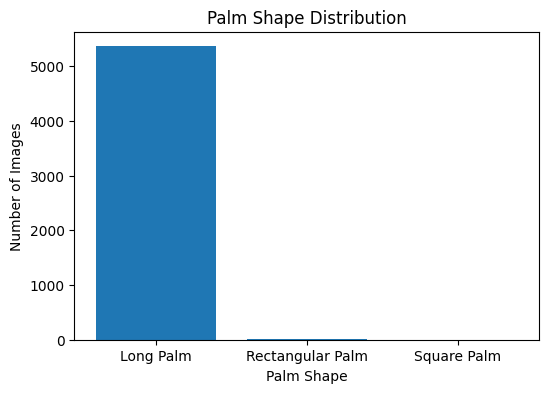

In [ ]:
import matplotlib.pyplot as plt

counts = df["palm_shape"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)

plt.title("Palm Shape Distribution")
plt.xlabel("Palm Shape")
plt.ylabel("Number of Images")

plt.show()

In [ ]:
df.to_csv("/content/palm_shape_classification.csv", index=False)

print("Palm shape classification saved successfully!")

Palm shape classification saved successfully!


In [ ]:
print(df["palm_ratio"].describe())

count    5380.000000
mean        1.960611
std         0.182291
min         0.909557
25%         1.854419
50%         1.968707
75%         2.083710
max         2.536204
Name: palm_ratio, dtype: float64


In [ ]:
import numpy as np

df["index_middle_spread"] = np.sqrt(
    (df["x8"] - df["x12"])**2 +
    (df["y8"] - df["y12"])**2
)

df["middle_ring_spread"] = np.sqrt(
    (df["x12"] - df["x16"])**2 +
    (df["y12"] - df["y16"])**2
)

df["ring_little_spread"] = np.sqrt(
    (df["x16"] - df["x20"])**2 +
    (df["y16"] - df["y20"])**2
)

In [ ]:
df["palm_center_x"] = (
    df["x0"] + df["x5"] + df["x9"] + df["x13"] + df["x17"]
) / 5

df["palm_center_y"] = (
    df["y0"] + df["y5"] + df["y9"] + df["y13"] + df["y17"]
) / 5

In [ ]:
for tip in [4, 8, 12, 16, 20]:
    df[f"wrist_tip_{tip}"] = np.sqrt(
        (df["x0"] - df[f"x{tip}"])**2 +
        (df["y0"] - df[f"y{tip}"])**2
    )

In [ ]:
df.to_csv("/content/palm_engineered_features_v2.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [ ]:
from google.colab import files

files.download("palm_engineered_features.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>